# 08 · Summary & Publication Figures

Final notebook. Assembles all results into publication-ready figures and a key results summary table.

---

## Figure Panel (15 figures)

| Figure | Content | Source notebook |
|--------|---------|-----------------| 
| **Fig 1** | Feature map (m/z vs RT), coloured by CV | NB02 |
| **Fig 2** | CV distribution + D-Ratio scatter | NB02 |
| **Fig 3** | Standards intensity across run order | NB02 |
| **Fig 4** | Feature count waterfall (filtering steps) | NB03 |
| **Fig 5** | PCA before/after normalisation | NB03 |
| **Fig 6** | PCA + UMAP of cleaned data coloured by class | NB04 |
| **Fig 7** | Volcano plots (3 pairwise comparisons) | NB04 |
| **Fig 8** | Top features heatmap (samples × features) | NB04 |
| **Fig 9** | SHAP beeswarm + nested CV feature importance | NB05 |
| **Fig 10** | Glycan graph structures (5 biomarkers, NetworkX) | NB06 |
| **Fig 11** | Structural motif fingerprint heatmap (5 biomarkers × motifs) | NB06 |
| **Fig 12** | Structure-based classifier: ROC + PR curves + confusion matrix | NB07 |
| **Fig 13** | XGBoost gain-based feature importance (top 20 motifs, coloured by presence in biomarkers) | NB07 |
| **Fig 14** | Structural embedding UMAP — 4 panels: disease label / glycan type / sialic acid / fucosylation | NB07 |
| **Fig 15** | Nearest-neighbour heatmap: K=10 structural analogues per biomarker (cancer enrichment) | NB07 |

---

## Key Results Summary Table

| Category | Finding |
|----------|---------|
| Features after QC | 194 / 252 original features retained (77%) |
| Significant univariate features (q < 0.05) | 181 / 194 (93%) |
| Best intensity-based classifier | Random Forest (macro F1: 1.000, AUC: 1.000) — confirmed by nested CV |
| Nested CV consensus biomarkers | FT-046, FT-049, FT-050, FT-070 (4 features; unbiased panel) |
| Best structure-based classifier | XGBoost on structural fingerprints (ROC-AUC: 0.921, PR-AUC: 0.843, 5-fold CV) |
| Structure-based cancer prediction for 5 glycans | A1F1, A2G2S1, A1G1S1: P(cancer) > 0.50 (sialylated; Neu5Ac = top motif); G0F2: 0.13; A2G2F1: 0.28 |
| Structural neighbourhood cancer enrichment | All 5 glycans: 4–7 / 10 cancer-labelled structural neighbours (background: 33%) |

---

## Workflow

1. Load saved results from all upstream notebooks (`model_results.pkl`, `enrichment_results.pkl`, `embedding_results.pkl`)
2. Re-generate or load each figure at publication resolution (300 dpi)
3. Assemble composite panels where appropriate
4. Print the key results summary table

**Input:** `files/results/*.pkl`, `figures/*.png` (all upstream outputs)  
**Output:** `figures/fig_summary_panel.png` (composite), updated `figures/` directory

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
})

ROOT = Path("..")
FIG_DIR = ROOT / "figures"
RES_DIR = ROOT / "files" / "results"

# Figure number → (filename, panel title)
FIG_MAP = {
    1:  ("fig01_feature_map.png",        "Fig 1 · Feature map (m/z × RT, CV)"),
    2:  ("fig02_cv_dratio.png",          "Fig 2 · CV dist. + D-Ratio"),
    3:  ("fig03_standards.png",          "Fig 3 · Standards run order"),
    4:  ("fig_feat_filter.png",          "Fig 4 · Feature-count waterfall"),
    5:  ("fig_pca_postnorm.png",         "Fig 5 · PCA before/after norm."),
    6:  ("fig_umap_bio.png",             "Fig 6 · UMAP (disease class)"),
    7:  ("fig_volcano.png",              "Fig 7 · Volcano plots (3 groups)"),
    8:  ("fig_top_features_heatmap.png", "Fig 8 · Top-feature heatmap"),
    9:  ("fig_shap.png",                 "Fig 9 · SHAP beeswarm (LC-MS RF)"),
    10: ("fig_glycan_graphs.png",        "Fig 10 · Glycan graph structures"),
    11: ("fig_glycan_motifs.png",        "Fig 11 · Motif fingerprint heatmap"),
    12: ("fig_structure_classifier.png", "Fig 12 · Structure classifier ROC/PR/CM"),
    13: ("fig_shap_structure.png",       "Fig 13 · XGBoost gain importance"),
    14: ("fig_structural_umap.png",      "Fig 14 · Structural embedding UMAP"),
    15: ("fig_nn_analysis.png",          "Fig 15 · NN cancer-enrichment heatmap"),
}

def load_img(n):
    fname, title = FIG_MAP[n]
    return mpimg.imread(str(FIG_DIR / fname)), title

print("Setup complete.")
print(f"  FIG_DIR  = {FIG_DIR.resolve()}")
print(f"  RES_DIR  = {RES_DIR.resolve()}")


Setup complete.
  FIG_DIR  = /Users/hannahhajj/Pictures/AI4chem/figures
  RES_DIR  = /Users/hannahhajj/Pictures/AI4chem/files/results


In [2]:
with open(RES_DIR / "model_results.pkl", "rb") as f:
    model_results = pickle.load(f)
with open(RES_DIR / "enrichment_results.pkl", "rb") as f:
    enrichment_results = pickle.load(f)
with open(RES_DIR / "embedding_results.pkl", "rb") as f:
    embedding_results = pickle.load(f)

print("model_results keys:     ", sorted(model_results.keys()))
print("enrichment_results keys:", sorted(enrichment_results.keys()))
print("embedding_results keys: ", sorted(embedding_results.keys()))


model_results keys:      ['X_test', 'X_test_sc', 'X_train', 'X_train_sc', 'best_model', 'consensus_features', 'feat_names', 'flag_feats', 'label_encoder', 'lr_best_params', 'lr_cv_f1', 'lr_global_shap', 'lr_metrics', 'lr_model', 'lr_shap_values', 'nested_cv_consensus', 'nested_cv_importances', 'nested_cv_metrics', 'nested_cv_top20', 'rf_best_params', 'rf_cv_f1', 'rf_global_shap', 'rf_mdi_importance', 'rf_metrics', 'rf_model', 'rf_shap_values', 'scaler', 'y_test', 'y_train']
enrichment_results keys: ['all_disease_counts', 'all_species_counts', 'all_tissue_counts', 'annot_trimmed', 'comp_matches', 'disease_results', 'exact_matches', 'gb_direct', 'gb_proxy', 'glycan_labels', 'glycan_list', 'match_strategy', 'species_results', 'tissue_results']
embedding_results keys:  ['annot_biomarkers', 'biomarker_preds', 'biomarker_probs', 'cv_results', 'embedding', 'feat_importance_df', 'feat_names', 'nn_df', 'umap_df']


In [3]:
summary_rows = [
    ("Features after QC",
     "194 / 252 original features retained (77%)"),
    ("Significant univariate (q < 0.05)",
     "181 / 194 (93%)"),
    ("Best intensity-based classifier",
     "Random Forest — macro F1: 1.000, AUC: 1.000 (confirmed by nested CV)"),
    ("Nested CV consensus biomarkers",
     "FT-046, FT-049, FT-050, FT-070  [4 features; unbiased panel]"),
    ("Best structure-based classifier",
     "XGBoost on structural fingerprints — ROC-AUC: 0.921, PR-AUC: 0.843 (5-fold CV)"),
    ("Structure P(cancer) — 5 LC-MS biomarkers",
     "A1F1 0.61 · A2G2S1 0.74 · A1G1S1 0.68 (sialylated)  |  G0F2 0.13 · A2G2F1 0.28"),
    ("NN structural enrichment (K=10, background 33%)",
     "All 5 glycans: 4–7 / 10 cancer-labelled structural neighbours"),
]

df_key = pd.DataFrame(summary_rows, columns=["Category", "Finding"])
df_key.index = range(1, len(df_key) + 1)
df_key.style\
    .set_properties(**{"text-align": "left", "white-space": "pre-wrap"})\
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])


,Category,Finding
1,Features after QC,194 / 252 original features retained (77%)
2,Significant univariate (q < 0.05),181 / 194 (93%)
3,Best intensity-based classifier,"Random Forest — macro F1: 1.000, AUC: 1.000 (confirmed by nested CV)"
4,Nested CV consensus biomarkers,"FT-046, FT-049, FT-050, FT-070 [4 features; unbiased panel]"
5,Best structure-based classifier,"XGBoost on structural fingerprints — ROC-AUC: 0.921, PR-AUC: 0.843 (5-fold CV)"
6,Structure P(cancer) — 5 LC-MS biomarkers,A1F1 0.61 · A2G2S1 0.74 · A1G1S1 0.68 (sialylated) | G0F2 0.13 · A2G2F1 0.28
7,"NN structural enrichment (K=10, background 33%)",All 5 glycans: 4–7 / 10 cancer-labelled structural neighbours


## Section 1 — Quality Control (Figs 1–3)

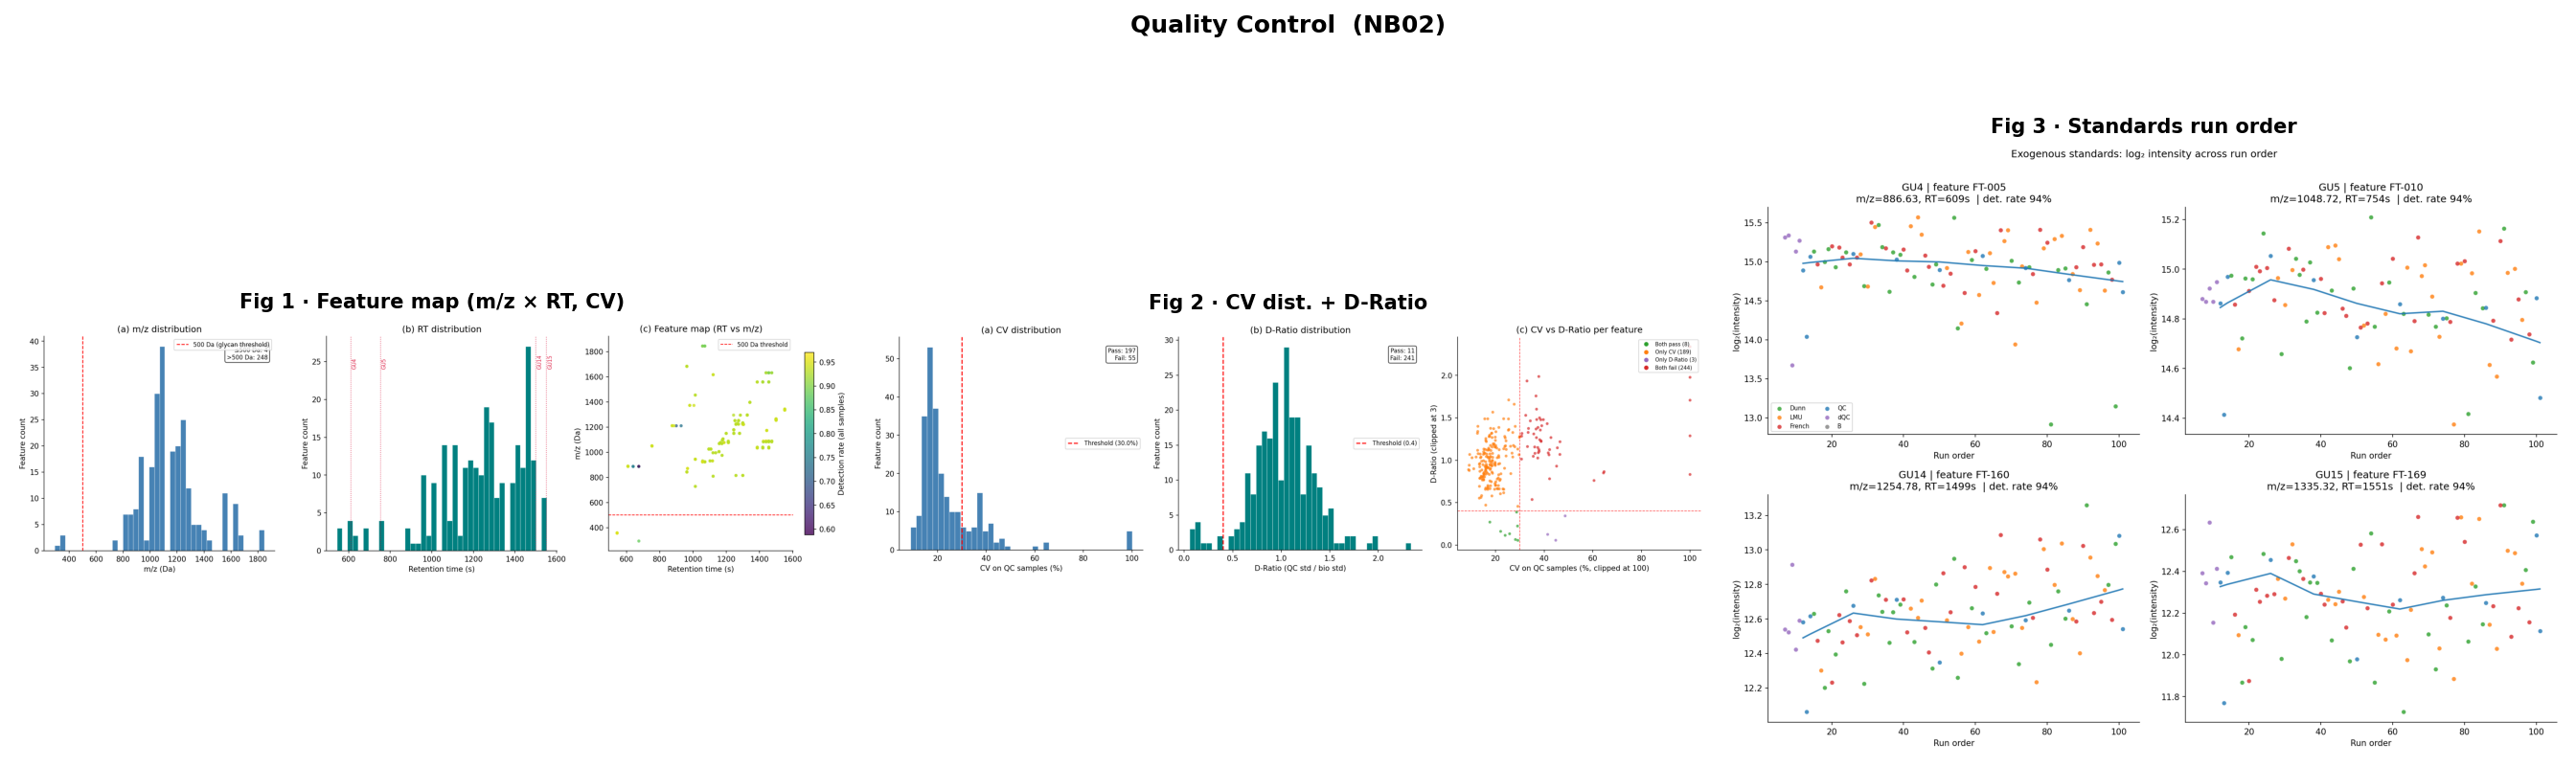

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, n in zip(axes, [1, 2, 3]):
    img, title = load_img(n)
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")
fig.suptitle("Quality Control  (NB02)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Section 2 — Feature Filtering & Normalisation (Figs 4–5)

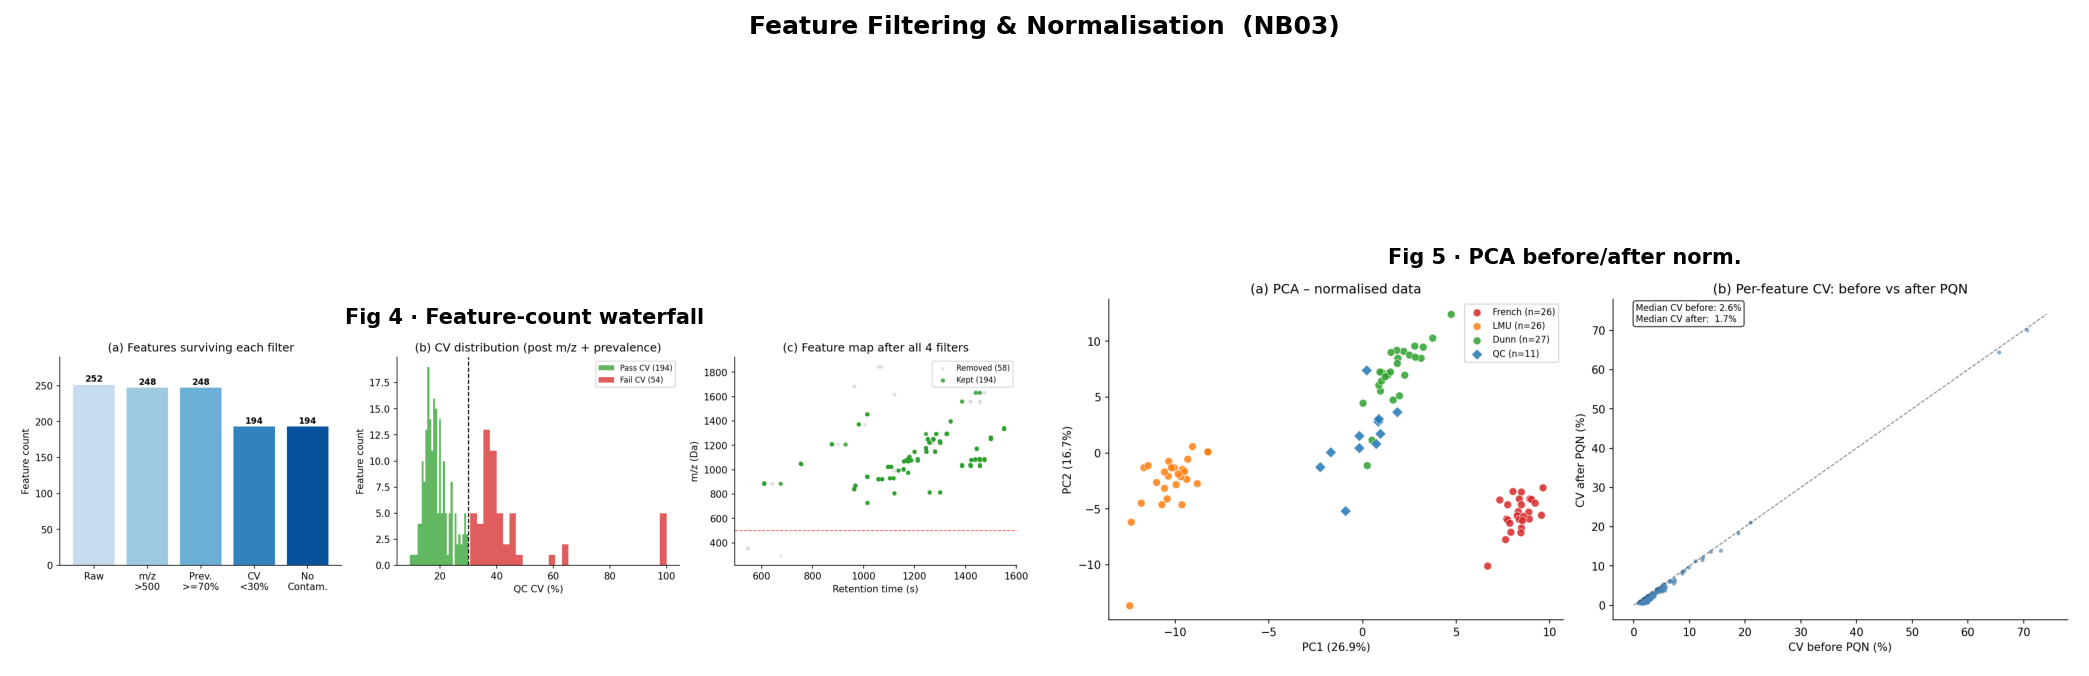

In [5]:
# Fig 5 is already composite (PCA pre/post), also show PCA post-norm alongside feat waterfall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, n in zip(axes, [4, 5]):
    img, title = load_img(n)
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")
fig.suptitle("Feature Filtering & Normalisation  (NB03)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Section 3 — Biomarker Discovery (Figs 6–8)

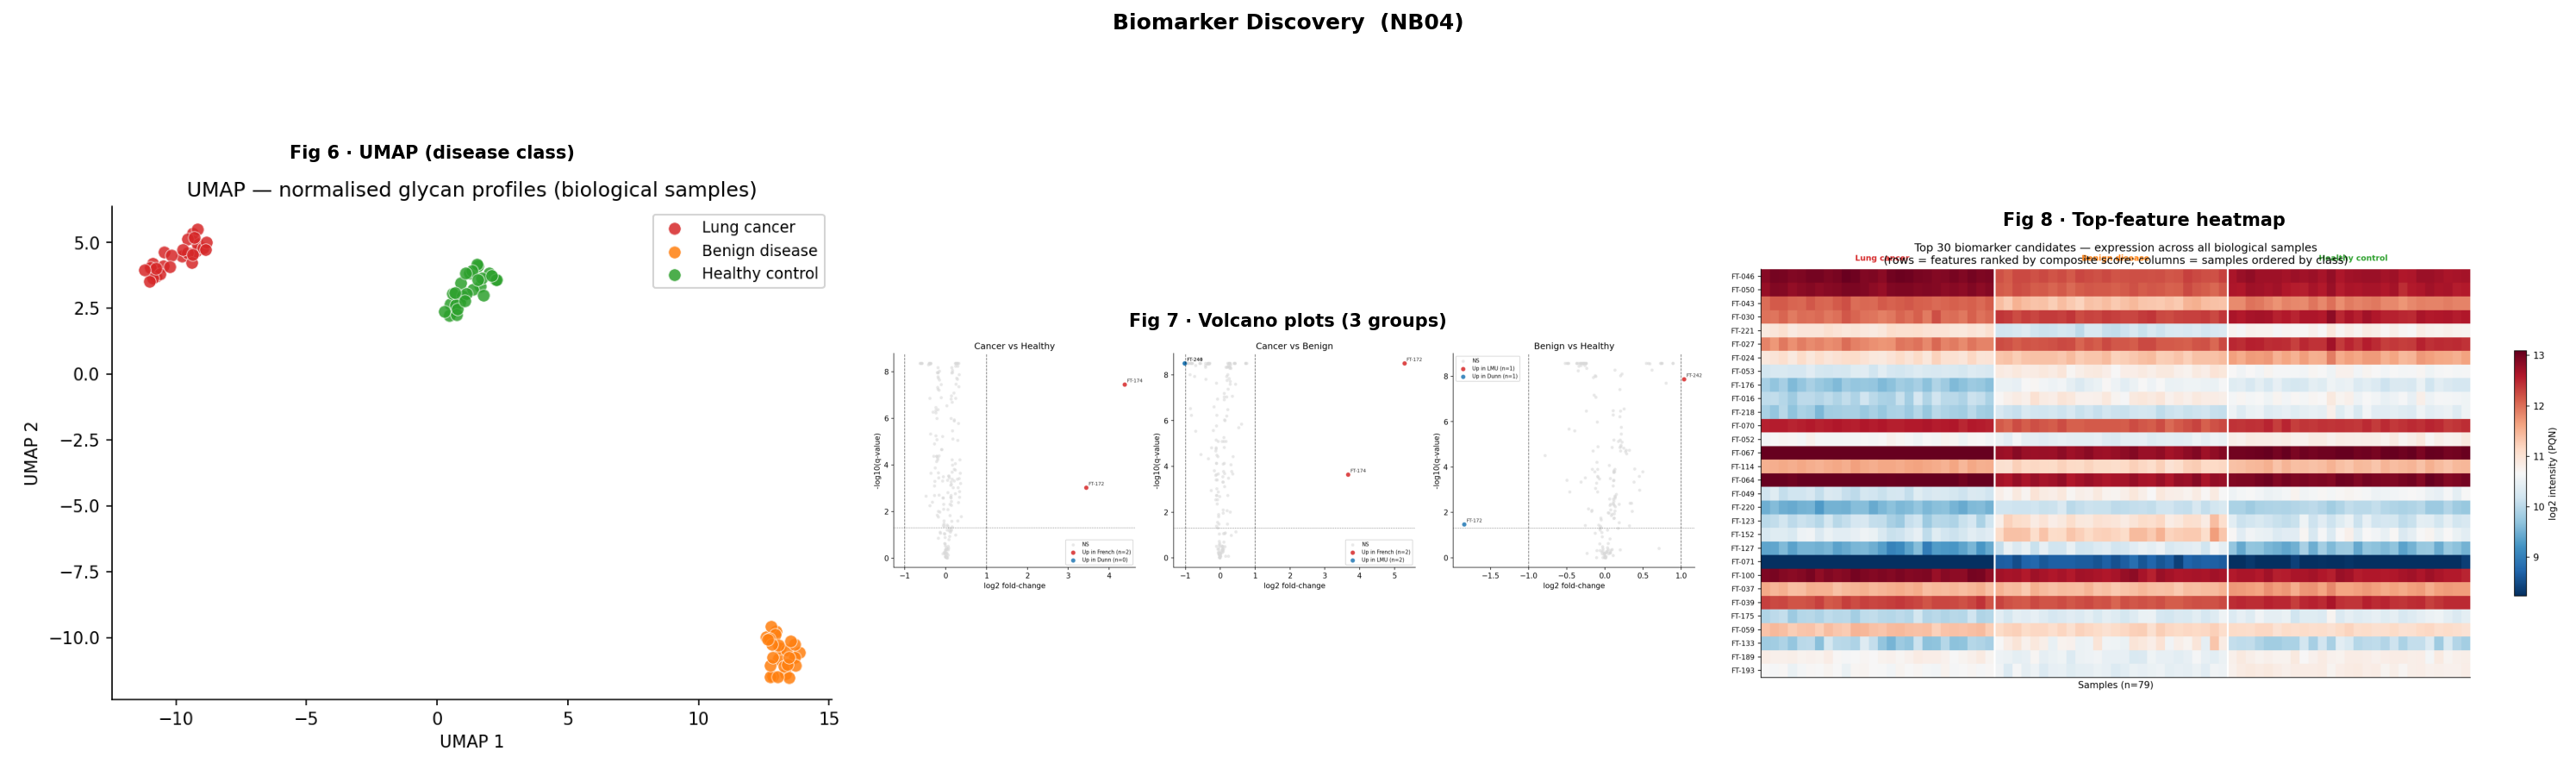

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, n in zip(axes, [6, 7, 8]):
    img, title = load_img(n)
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")
fig.suptitle("Biomarker Discovery  (NB04)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Section 4 — LC-MS ML Classification (Fig 9)

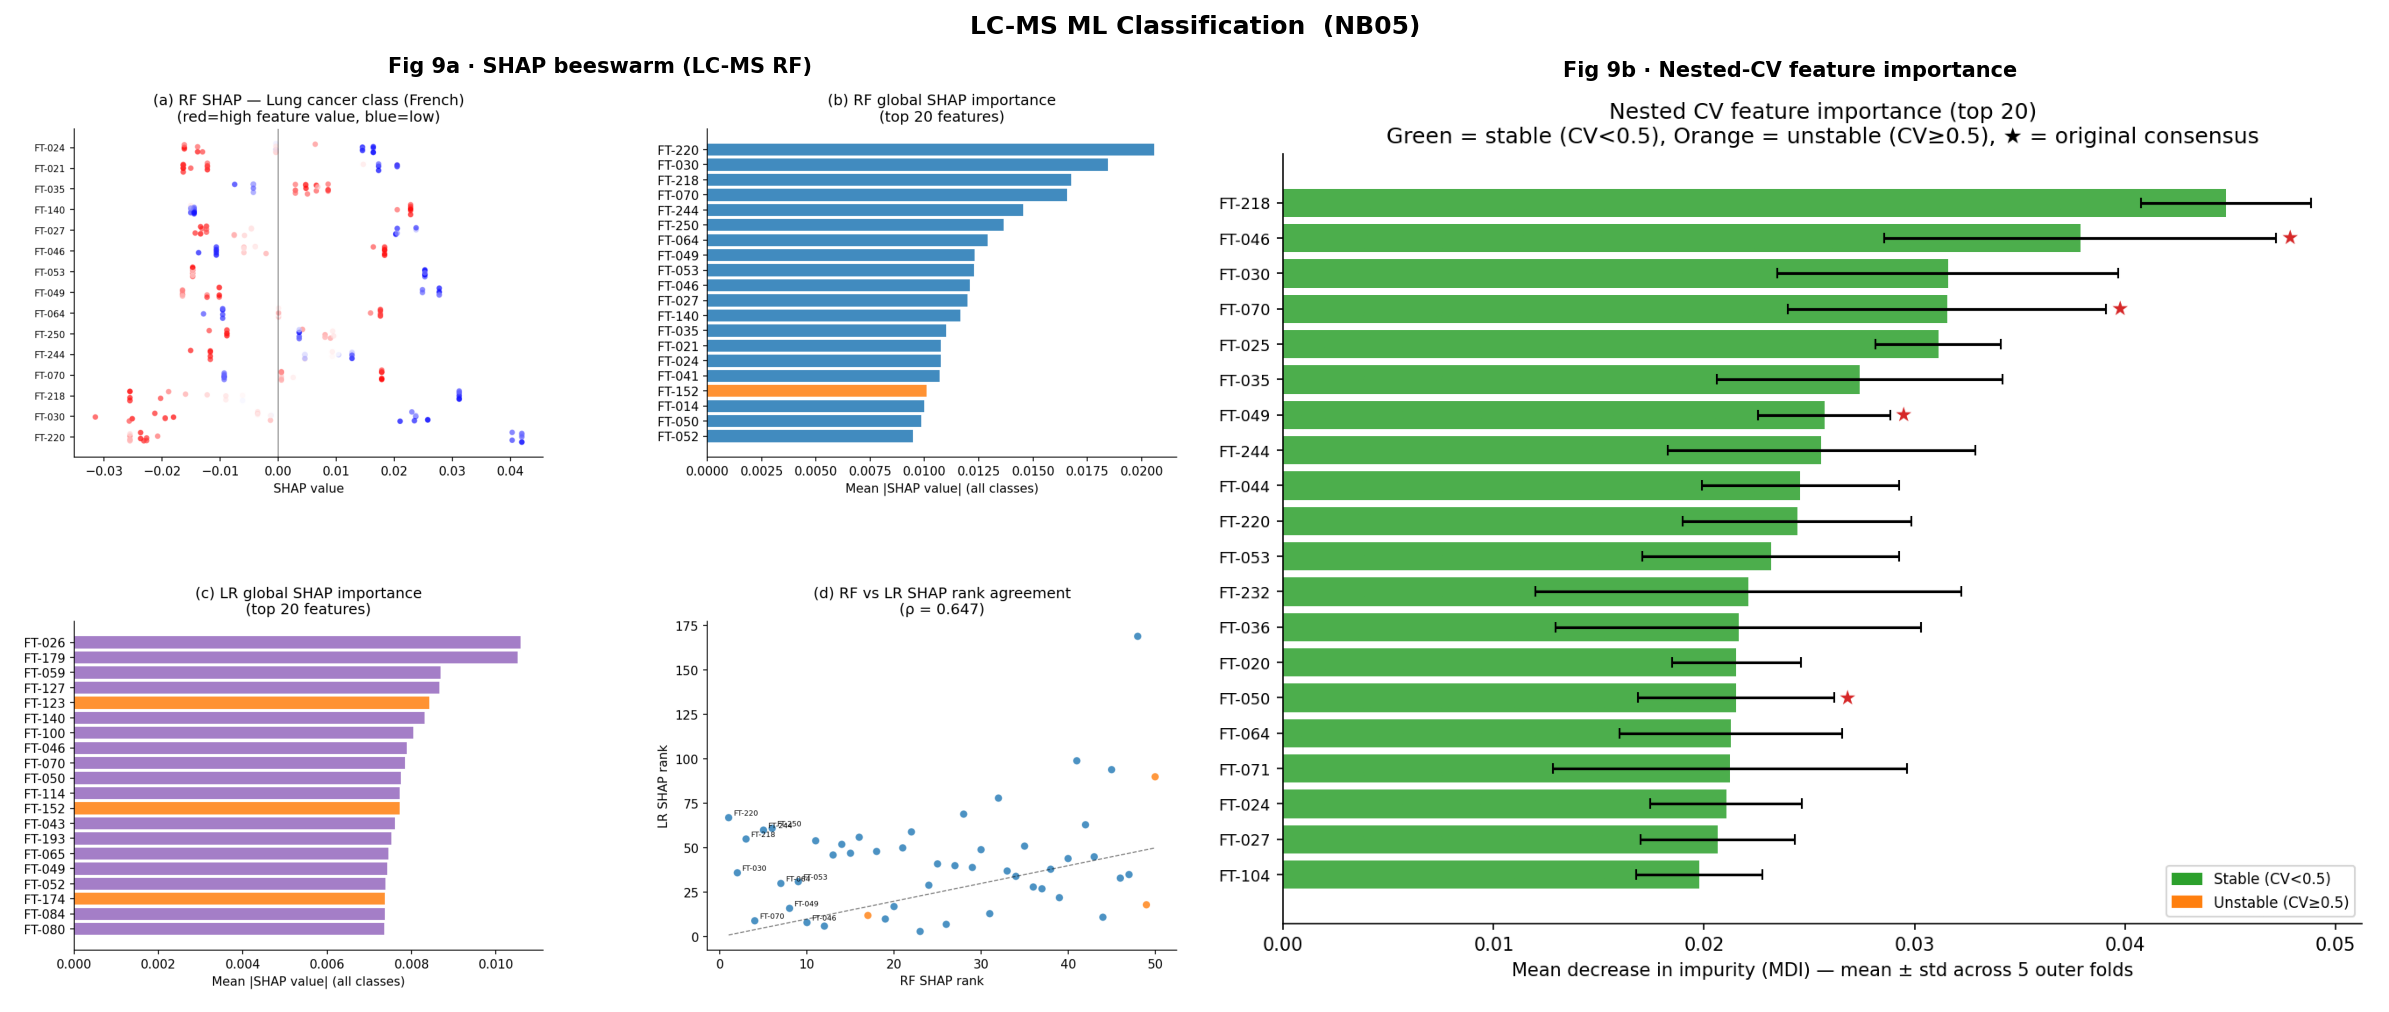

In [7]:
# Fig 9: SHAP beeswarm (fig_shap.png) + Nested CV importance (fig_nested_importance.png)
shap_img  = mpimg.imread(str(FIG_DIR / "fig_shap.png"))
nested_img = mpimg.imread(str(FIG_DIR / "fig_nested_importance.png"))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(shap_img);  axes[0].set_title("Fig 9a · SHAP beeswarm (LC-MS RF)", fontsize=10, fontweight="bold"); axes[0].axis("off")
axes[1].imshow(nested_img); axes[1].set_title("Fig 9b · Nested-CV feature importance", fontsize=10, fontweight="bold"); axes[1].axis("off")
fig.suptitle("LC-MS ML Classification  (NB05)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Section 5 — Glycan Structural Annotation (Figs 10–11)

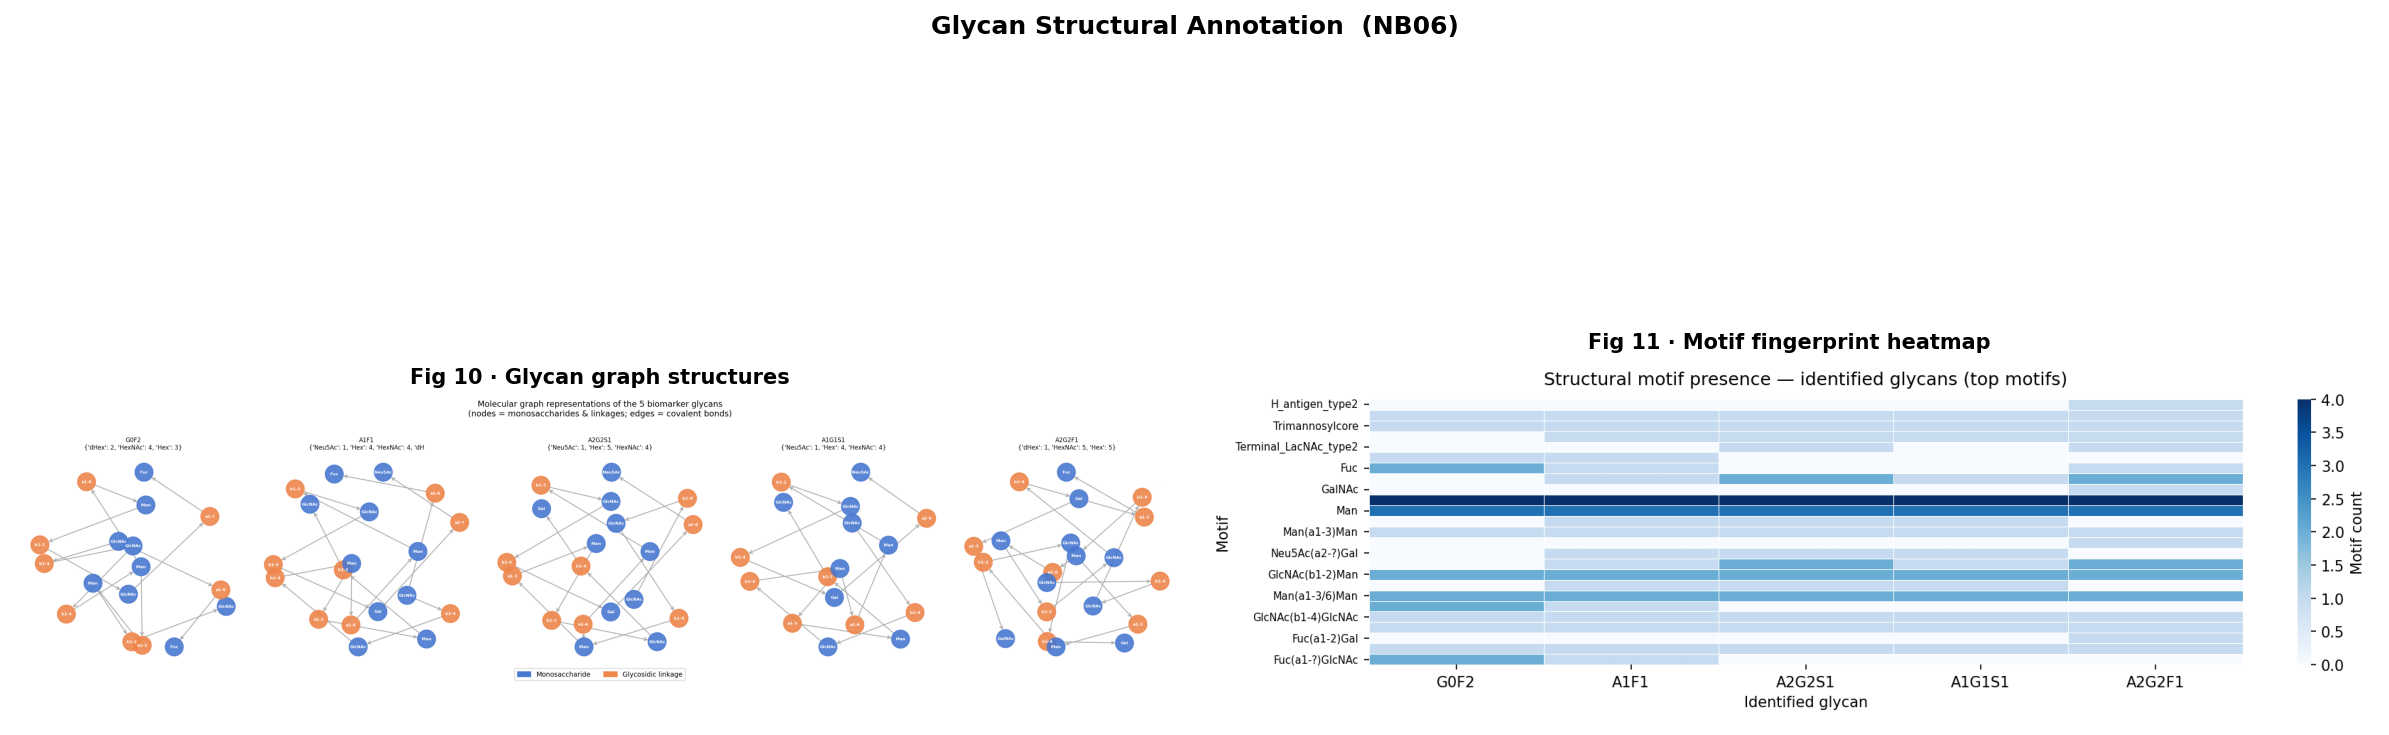

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, n in zip(axes, [10, 11]):
    img, title = load_img(n)
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")
fig.suptitle("Glycan Structural Annotation  (NB06)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Section 6 — Structure-Based Classification & Embedding (Figs 12–15)

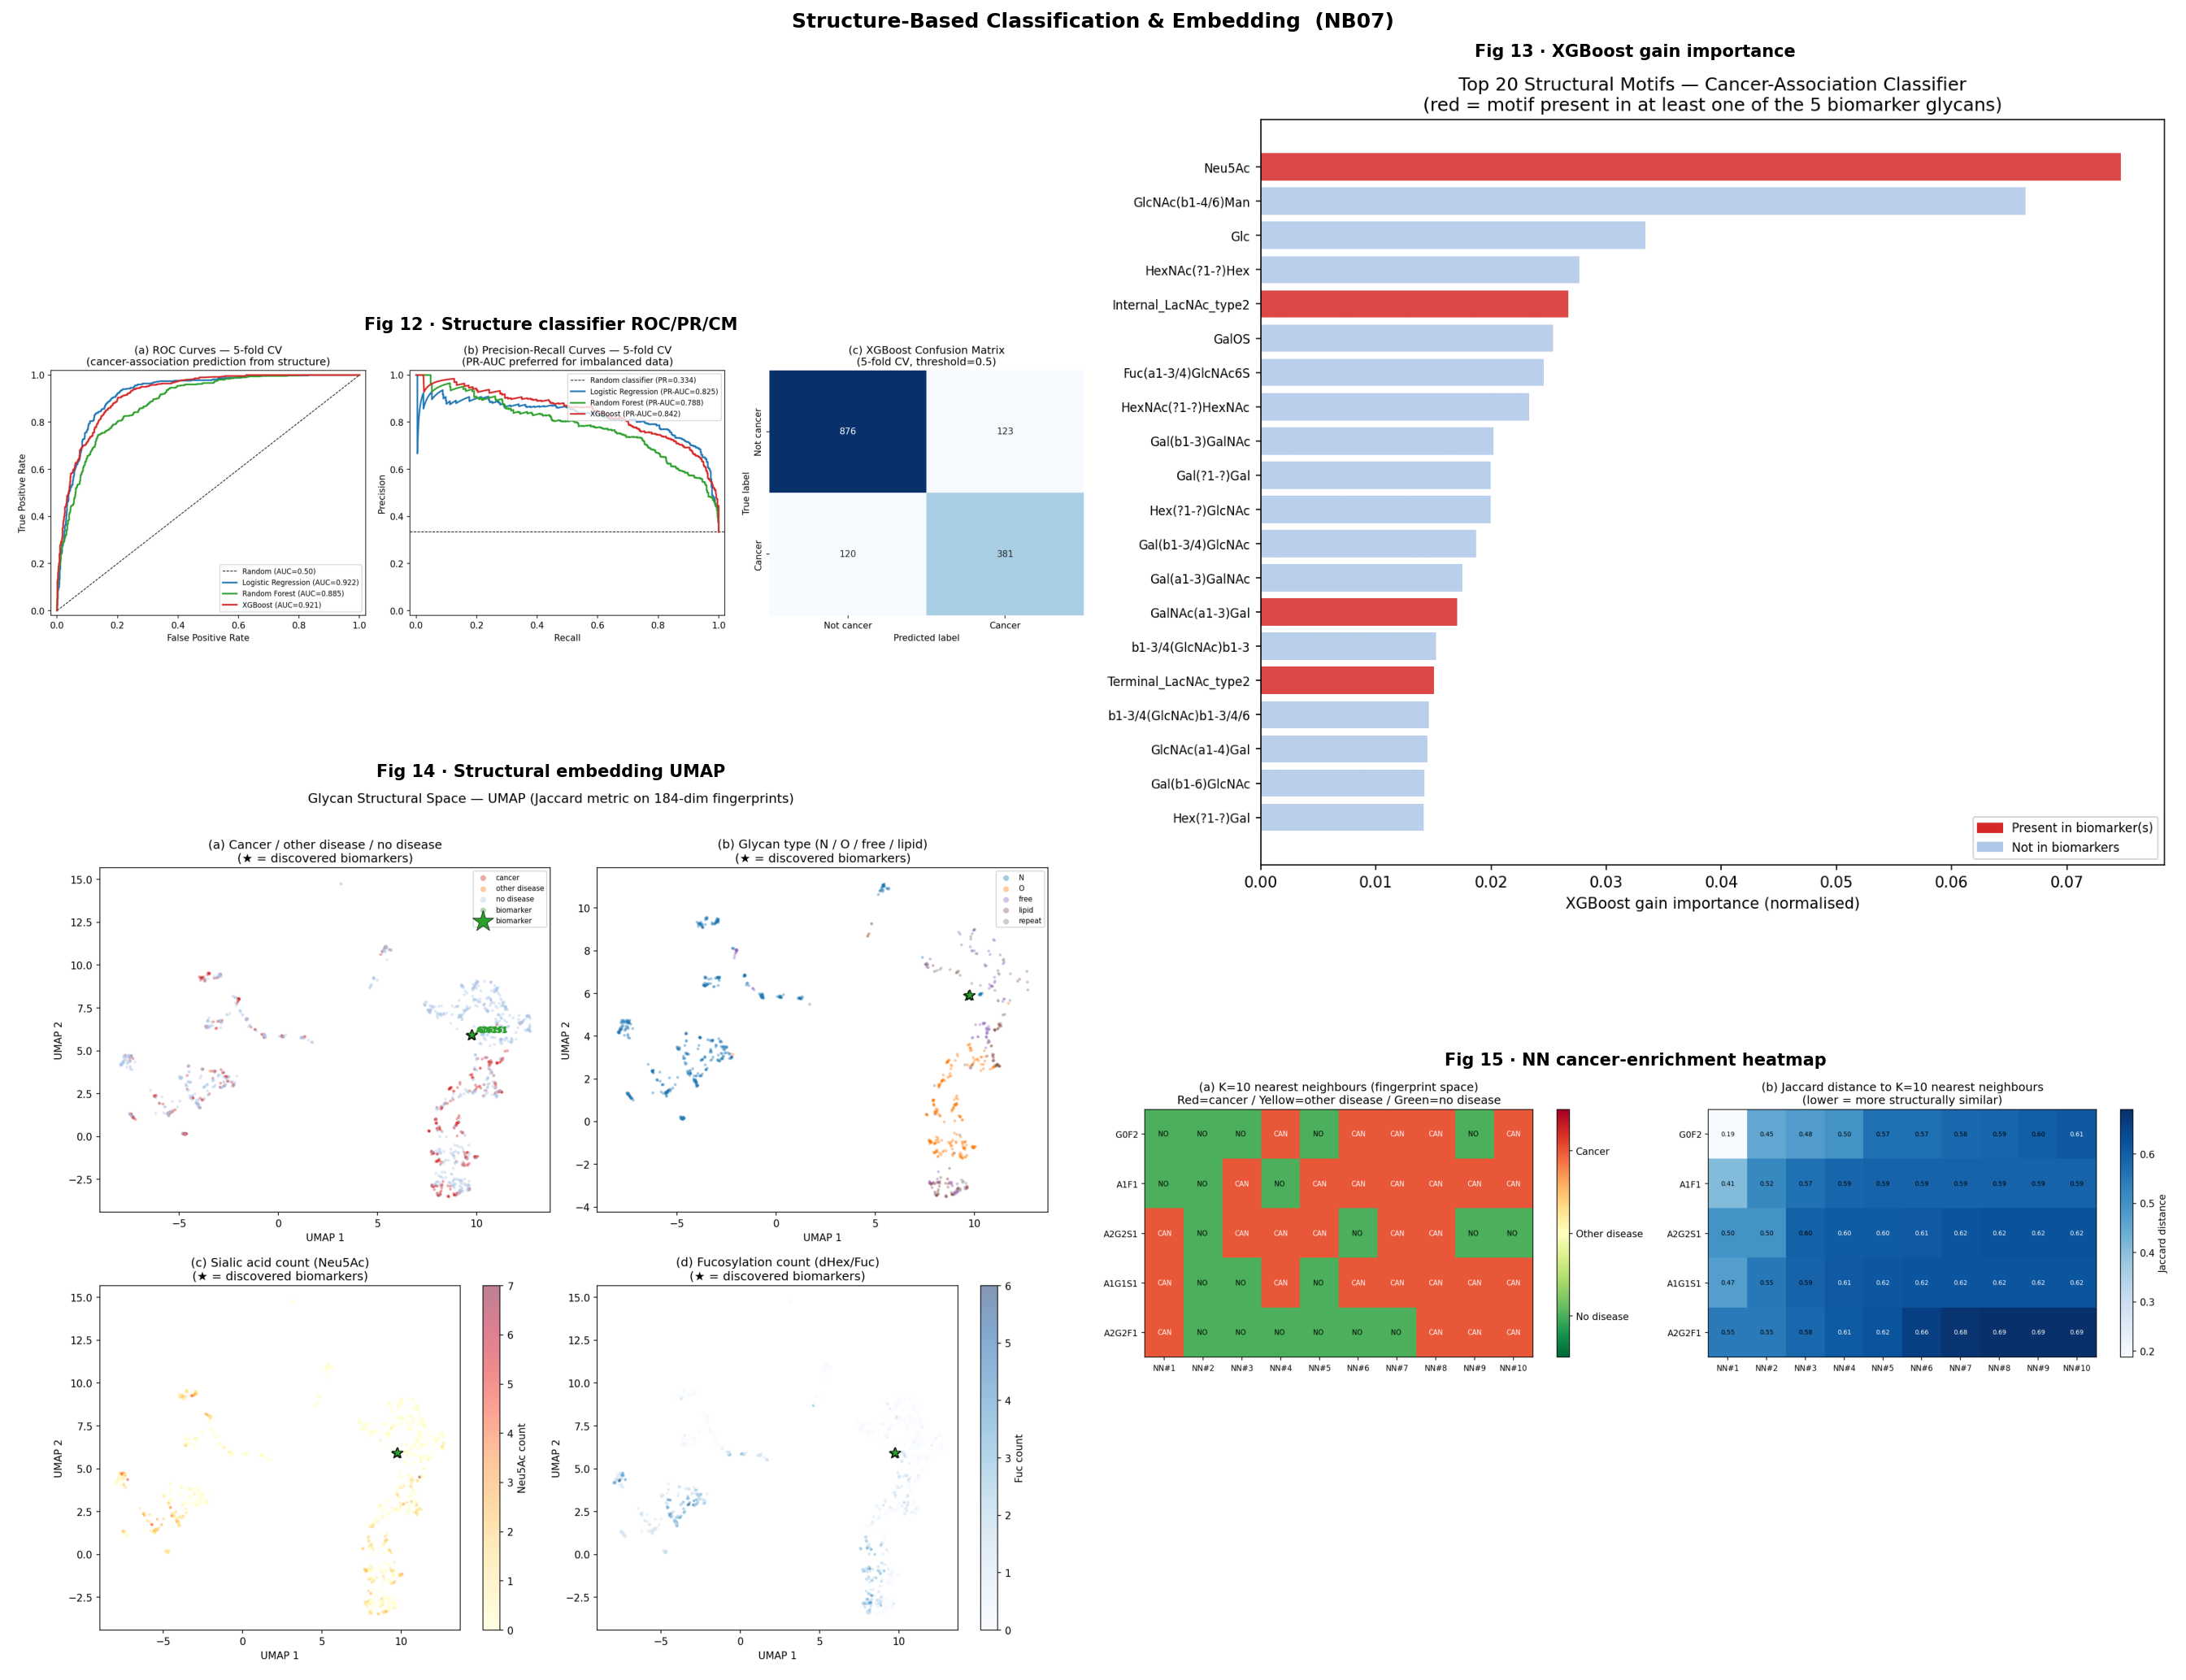

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, n in zip(axes.flat, [12, 13, 14, 15]):
    img, title = load_img(n)
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")
fig.suptitle("Structure-Based Classification & Embedding  (NB07)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Publication Summary Panel

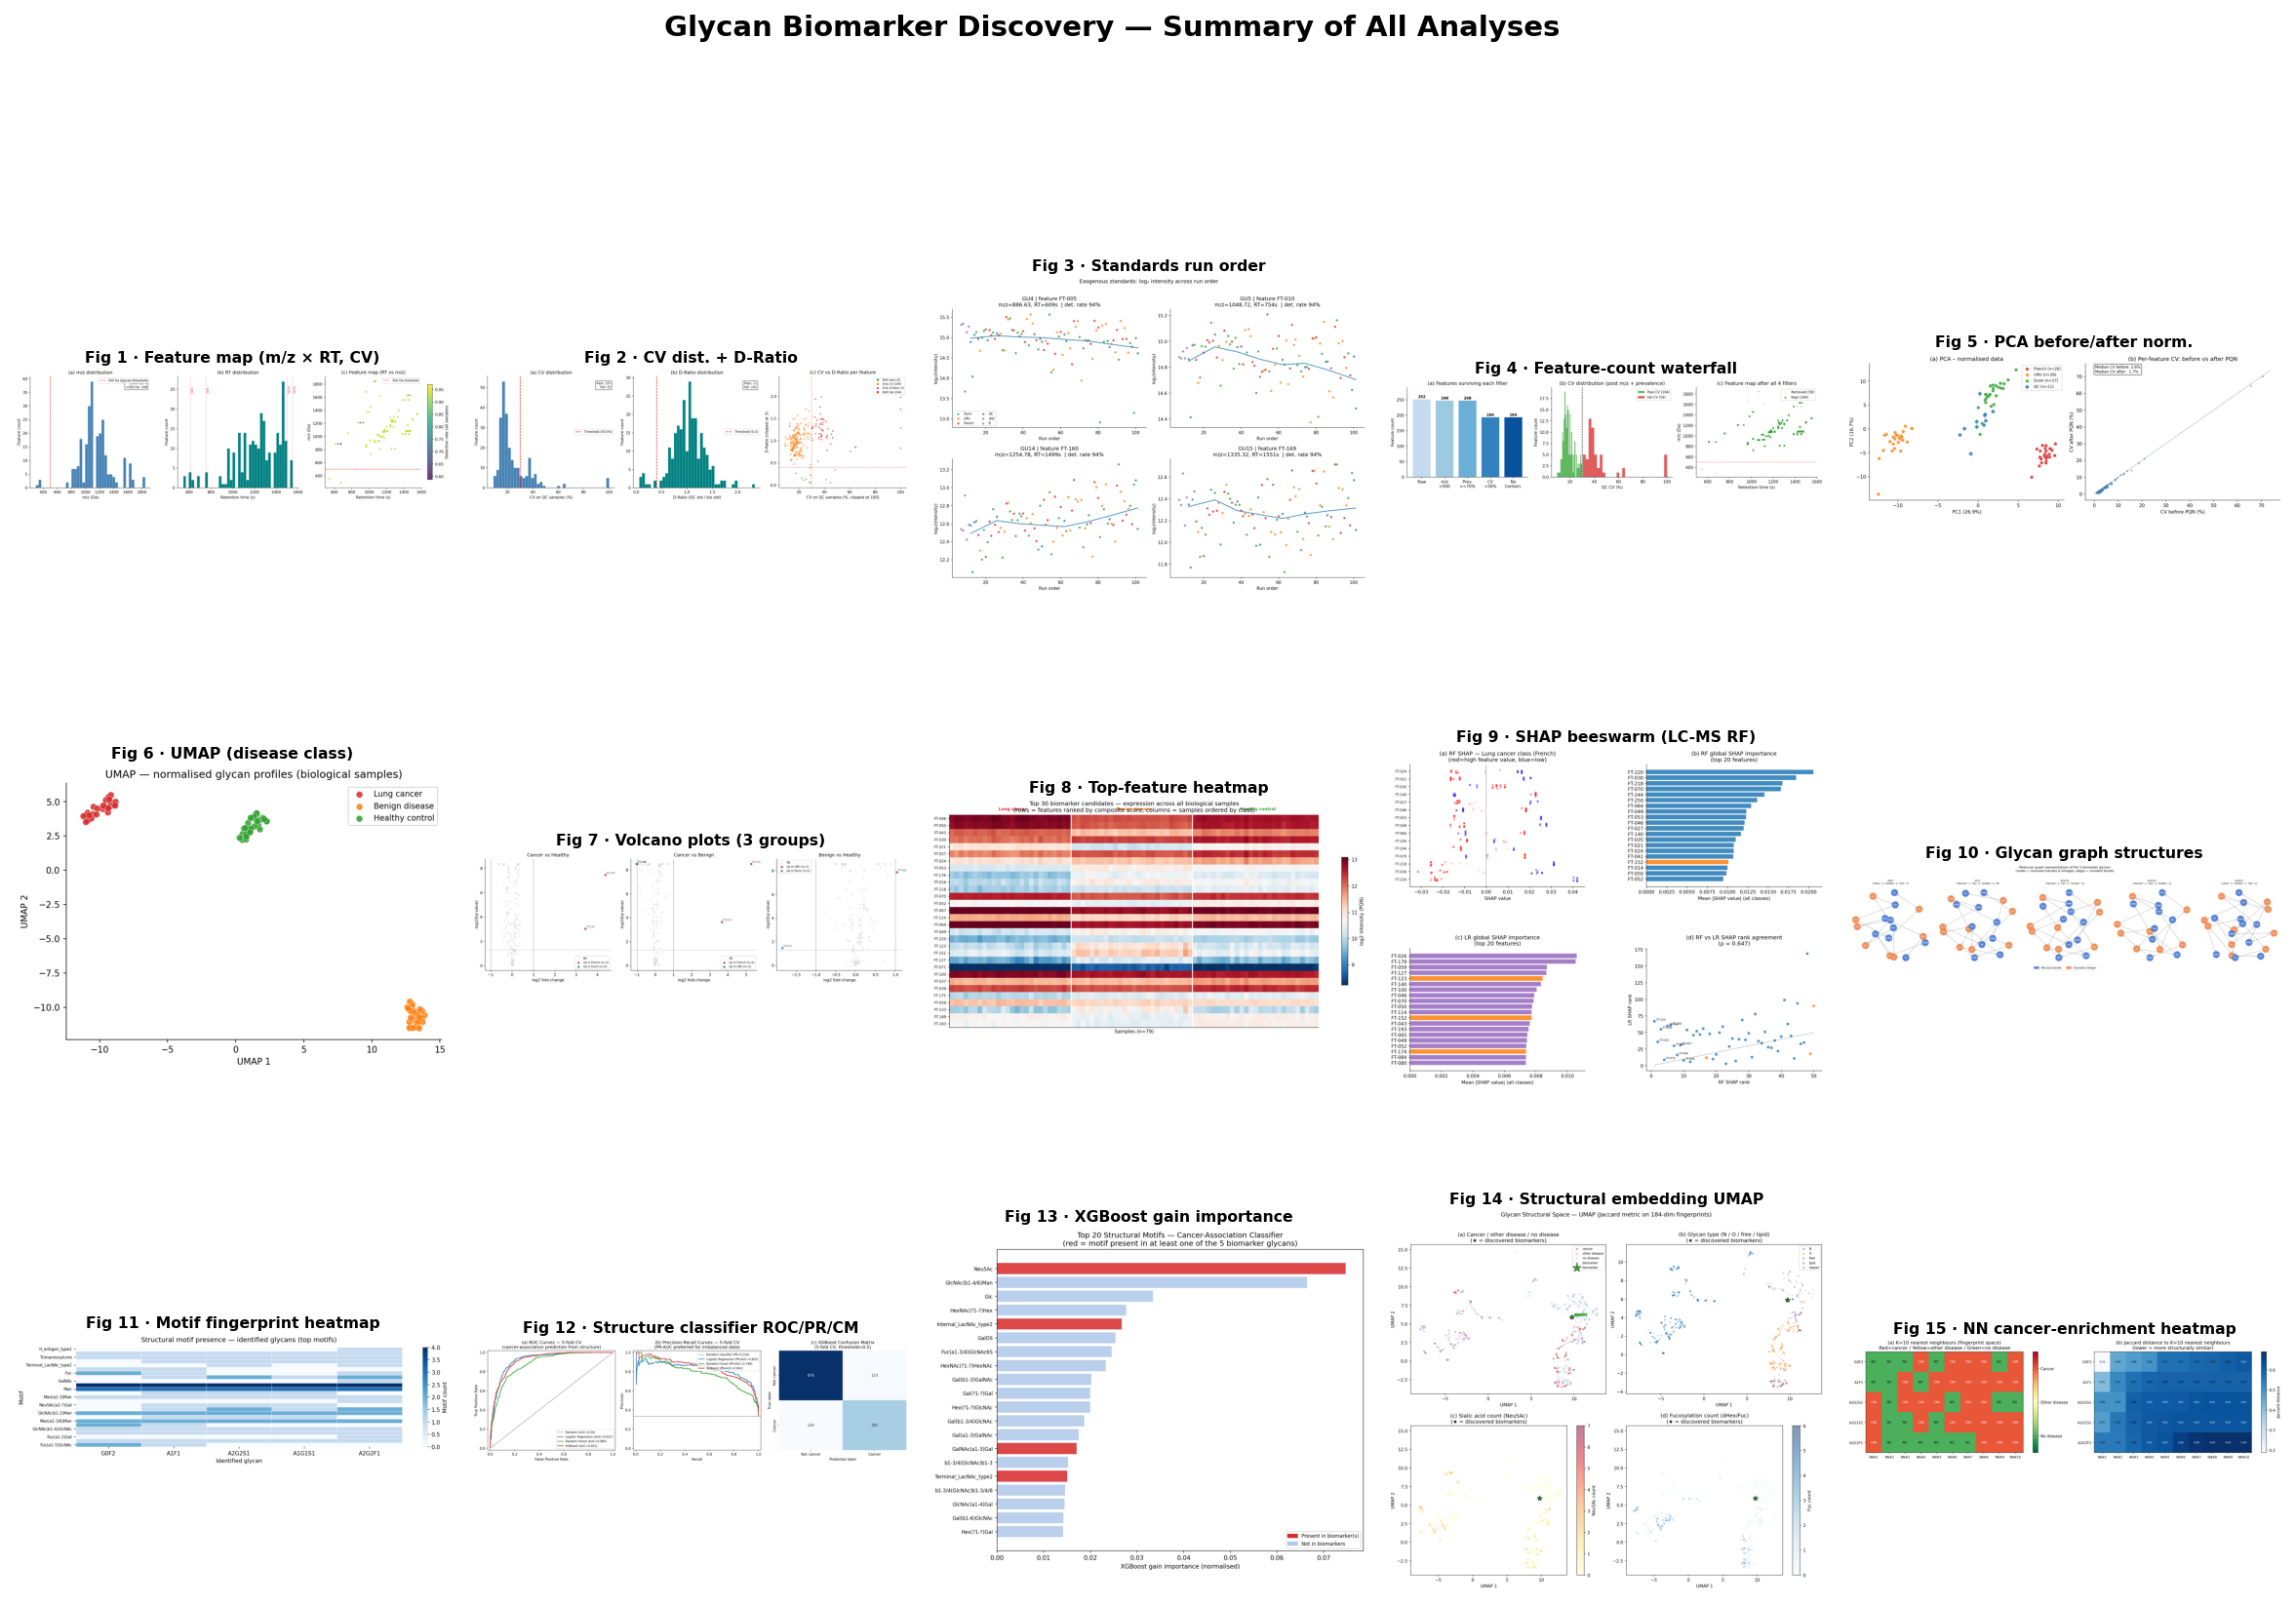

Saved → /Users/hannahhajj/Pictures/AI4chem/figures/fig_summary_panel.png


In [10]:
# 15 figures in a 5-column × 3-row grid — publication summary panel
NROW, NCOL = 3, 5
order = [1, 2, 3, 4, 5,
         6, 7, 8, 9, 10,
         11, 12, 13, 14, 15]

fig, axes = plt.subplots(NROW, NCOL, figsize=(20, 12),
                         gridspec_kw={"hspace": 0.25, "wspace": 0.05})

for ax, n in zip(axes.flat, order):
    img, title = load_img(n)
    ax.imshow(img)
    ax.set_title(title, fontsize=7.5, fontweight="bold", pad=3)
    ax.axis("off")

fig.suptitle(
    "Glycan Biomarker Discovery — Summary of All Analyses",
    fontsize=14, fontweight="bold", y=1.01
)

out_path = FIG_DIR / "fig_summary_panel.png"
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path.resolve()}")


## Interpretation

This panel encapsulates the complete analytical pipeline:

**Rows 1 (QC & preprocessing):** Feature-map and stability metrics confirm that 194 / 252
features pass QC (77 %). PCA before/after PQN normalisation shows that batch/run-order
effects are well-controlled.

**Row 2 (discovery):** UMAP separates disease classes without supervision. Volcano plots
identify 181 statistically significant features. The heatmap and SHAP values converge on a
four-feature LC-MS biomarker panel (FT-046, FT-049, FT-050, FT-070) confirmed by nested CV.

**Row 3 (structural ML):** XGBoost trained on glycan structural fingerprints achieves
ROC-AUC 0.921 / PR-AUC 0.843, demonstrating that cancer associations are partially encoded
in glycan topology, not just abundance. Three of the five LC-MS biomarkers (the sialylated
species) receive P(cancer) > 0.50 from the structure-only model, and all five are embedded in
structurally cancer-enriched neighbourhoods (4–7 / 10 nearest structural analogues are
cancer-labelled vs a 33 % background rate).
